## given isolated clusters of drifters, create contours of the watersheds and find the areas of the contours considering a spherical earth.


#### import and define clusters


In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import Polygon


In [2]:
PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "watershed_ids").exists():
    PROJECT_DIR = Path("/home/codycruz/drifters_watersheds")

parquet_path = PROJECT_DIR / "undrogued_beach.parquet"
csv_path = PROJECT_DIR / "undrogued_beach.csv"

if parquet_path.exists():
    beach_undrogued = pd.read_parquet(
        parquet_path,
        columns=["id", "lat", "lon", "time_to_beach"],
    )
elif csv_path.exists():
    beach_undrogued = pd.read_csv(
        csv_path,
        usecols=["id", "lat", "lon", "time_to_beach"],
    )
else:
    raise FileNotFoundError(
        f"Could not find either {parquet_path.name} or {csv_path.name} in {PROJECT_DIR}"
    )

beach_undrogued.head()


,id,lat,lon,time_to_beach
0,101510,22.43137,120.45541,363600.0
1,101510,22.43232,120.45519,360000.0
2,101510,22.43020,120.45683,356400.0
3,101510,22.42962,120.45589,352800.0
4,101510,22.42837,120.45268,349200.0


In [13]:
watershed_order = [
    "W_Indian",
    "S_Central_Pacific",
    "W_Pacific",
    "W_Central_Pacific",
    "NW_Atlantic",
    "SO_S_America",
    "NE_Atlantic",
    "SW_Atlantic",
    "N_Indian",
    "SW_Pacific",
    "Mid_Atlantic",
    "N_Pacific",
    "SO_West_Australia",
    "Tasman_Sea",
    "SO_East_Australia",
    "E_Central_Pacific",
]


id_dataframes = {
    name: PROJECT_DIR / "watershed_ids" / f"{name}_ids.csv"
    for name in watershed_order
}

missing_files = [path for path in id_dataframes.values() if not path.exists()]
if missing_files:
    missing_text = "\n".join(str(path) for path in missing_files)
    raise FileNotFoundError(f"Missing watershed ID files:\n{missing_text}")

loaded_ids = {name: pd.read_csv(path) for name, path in id_dataframes.items()}

pd.Series({name: len(df) for name, df in loaded_ids.items()}, name="trajectory_ids")


W_Indian             241
S_Central_Pacific    285
W_Pacific            305
W_Central_Pacific     87
NW_Atlantic          267
SO_S_America         147
NE_Atlantic          303
SW_Atlantic          133
N_Indian              60
SW_Pacific            85
Mid_Atlantic         103
N_Pacific            163
SO_West_Australia     35
Tasman_Sea            64
SO_East_Australia     60
E_Central_Pacific     42
Name: trajectory_ids, dtype: int64

In [14]:
id_lookup = pd.concat(
    [
        df[["id"]].dropna().astype({"id": int}).assign(watershed=name)
        for name, df in loaded_ids.items()
    ],
    ignore_index=True,
).drop_duplicates()

if id_lookup["id"].duplicated().any():
    duplicate_ids = id_lookup.loc[id_lookup["id"].duplicated(), "id"].tolist()
    raise ValueError(f"Duplicate IDs were assigned to multiple watersheds: {duplicate_ids[:10]}")

watershed_points = beach_undrogued[beach_undrogued["id"].isin(id_lookup["id"])].copy()
watershed_points = watershed_points.merge(id_lookup, on="id", how="inner")

grouped_watersheds = {
    name: group[["id", "lat", "lon", "time_to_beach"]].copy()
    for name, group in watershed_points.groupby("watershed", sort=False)
}

empty_watershed = pd.DataFrame(columns=["id", "lat", "lon", "time_to_beach"])
watersheds = {
    name: grouped_watersheds.get(name, empty_watershed).copy()
    for name in watershed_order
}

pd.DataFrame(
    {
        "points": [len(watersheds[name]) for name in watershed_order],
        "unique_ids": [watersheds[name]["id"].nunique() for name in watershed_order],
    },
    index=watershed_order,
)


,points,unique_ids
W_Indian,2247920,241
S_Central_Pacific,2139210,285
W_Pacific,1150089,305
W_Central_Pacific,883209,87
NW_Atlantic,1877124,267
SO_S_America,1384297,147
NE_Atlantic,1575473,303
SW_Atlantic,701670,133
N_Indian,174224,60
SW_Pacific,527365,85


#### sort cluster trajectories into their time based groups using functions: 1 month, 3 months, 6 months, 1 year


In [15]:
TIME_WINDOWS = {
    "1 month": 2_629_800,
    "3 months": 7_776_000,
    "6 months": 15_638_400,
    "12 months": 31_536_000,
}
PERIOD_ORDER = ["12 months", "6 months", "3 months", "1 month"]
DISPLAY_LABELS = [name.replace("_", " ") for name in watershed_order]

n_lons, n_lats = 135, 85
lon_bins = np.linspace(-180, 180, n_lons + 1)
lat_bins = np.linspace(-90, 90, n_lats + 1)
lon_centers = (lon_bins[:-1] + lon_bins[1:]) / 2
lat_centers = (lat_bins[:-1] + lat_bins[1:]) / 2

def preprocess_data(df):
    cleaned = df.copy()
    cleaned["lat"] = pd.to_numeric(cleaned["lat"], errors="coerce")
    cleaned["lon"] = pd.to_numeric(cleaned["lon"], errors="coerce")
    cleaned["time_to_beach"] = pd.to_numeric(cleaned["time_to_beach"], errors="coerce")
    return cleaned.dropna(subset=["lat", "lon", "time_to_beach"])

def filter_to_window(cluster, max_seconds):
    return cluster.loc[cluster["time_to_beach"] <= max_seconds].copy()

def one_to_beach(cluster):
    return filter_to_window(cluster, TIME_WINDOWS["1 month"])

def three_to_beach(cluster):
    return filter_to_window(cluster, TIME_WINDOWS["3 months"])

def six_to_beach(cluster):
    return filter_to_window(cluster, TIME_WINDOWS["6 months"])

def year_to_beach(cluster):
    return filter_to_window(cluster, TIME_WINDOWS["12 months"])

def histogram_for_watershed(cluster, max_seconds):
    filtered = preprocess_data(filter_to_window(cluster, max_seconds))
    if filtered.empty:
        return np.zeros((len(lat_bins) - 1, len(lon_bins) - 1))

    heatmap_data, _, _ = np.histogram2d(
        filtered["lat"].values,
        filtered["lon"].values,
        bins=[lat_bins, lon_bins],
        density=False,
    )
    return heatmap_data


#### define the times to beach (1yr, 6m, 3m, 1m) and dataframe


In [16]:
AREA_PROJECTION_EPSG = 6933
REGION_CONTOUR_LEVEL = 100
TOTAL_OCEAN_AREA_KM2 = 361_132_000

def contour_area_from_segments(segments):
    total_area_m2 = 0.0

    for polygon_coords in segments:
        if len(polygon_coords) < 3:
            continue

        if not np.array_equal(polygon_coords[0], polygon_coords[-1]):
            polygon_coords = np.vstack([polygon_coords, polygon_coords[0]])

        polygon = Polygon(polygon_coords)
        if not polygon.is_valid:
            polygon = polygon.buffer(0)
        if polygon.is_empty:
            continue

        geometry = gpd.GeoDataFrame(geometry=[polygon], crs="EPSG:4326").to_crs(
            epsg=AREA_PROJECTION_EPSG
        )
        total_area_m2 += float(geometry.geometry.area.iloc[0])

    return total_area_m2 / 1_000_000

def contour_area_from_heatmap(heatmap_data, contour_level=REGION_CONTOUR_LEVEL):
    if float(np.nanmax(heatmap_data)) < contour_level:
        return 0.0

    fig, ax = plt.subplots(figsize=(10, 6))
    contour = ax.contour(
        lon_centers,
        lat_centers,
        heatmap_data,
        levels=[contour_level],
        colors="white",
    )
    plt.close(fig)

    if not contour.allsegs or not contour.allsegs[0]:
        return 0.0

    return contour_area_from_segments(contour.allsegs[0])

def plot_area_bars(area_results, title, color="skyblue"):
    values = [area_results[region] for region in watershed_order]

    plt.figure(figsize=(12, 6))
    plt.bar(DISPLAY_LABELS, values, color=color)
    plt.xlabel("Regions")
    plt.ylabel("Total Area (km²)")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

histograms_by_period = {
    period_label: {
        region: histogram_for_watershed(cluster, TIME_WINDOWS[period_label])
        for region, cluster in watersheds.items()
    }
    for period_label in TIME_WINDOWS
}

area_results_by_period = {
    period_label: {
        region: contour_area_from_heatmap(heatmap)
        for region, heatmap in region_heatmaps.items()
    }
    for period_label, region_heatmaps in histograms_by_period.items()
}

area_table = pd.DataFrame(area_results_by_period).T[watershed_order]
area_table


,W_Indian,S_Central_Pacific,W_Pacific,W_Central_Pacific,NW_Atlantic,SO_S_America,NE_Atlantic,SW_Atlantic,N_Indian,SW_Pacific,Mid_Atlantic,N_Pacific,SO_West_Australia,Tasman_Sea,SO_East_Australia,E_Central_Pacific
1 month,1.096208e+07,1.285046e+07,1.339480e+07,5.389658e+06,8.279926e+06,3.654901e+06,7.941280e+06,3.716726e+06,4.549508e+06,4.830151e+06,3.459681e+06,3.940888e+06,1.402938e+06,2.135502e+06,1.874649e+06,2.563776e+06
3 months,1.783567e+07,2.072941e+07,2.032259e+07,1.122450e+07,1.404530e+07,7.531939e+06,1.191439e+07,8.727280e+06,7.971247e+06,8.845191e+06,7.109709e+06,5.713419e+06,3.360005e+06,3.601799e+06,3.507243e+06,4.159086e+06
6 months,2.562516e+07,2.772114e+07,2.670326e+07,1.891067e+07,2.117874e+07,1.231659e+07,1.501157e+07,1.247122e+07,1.228332e+07,1.198703e+07,9.637946e+06,7.337620e+06,6.186763e+06,6.272112e+06,5.233999e+06,6.319715e+06
12 months,4.232258e+07,4.081235e+07,3.234820e+07,3.127921e+07,2.802486e+07,1.962123e+07,1.950566e+07,1.664732e+07,1.611870e+07,1.501207e+07,1.092398e+07,9.903546e+06,9.900043e+06,9.570979e+06,9.098060e+06,7.574176e+06


#### individual plots


12 months: 318,662,976 km²


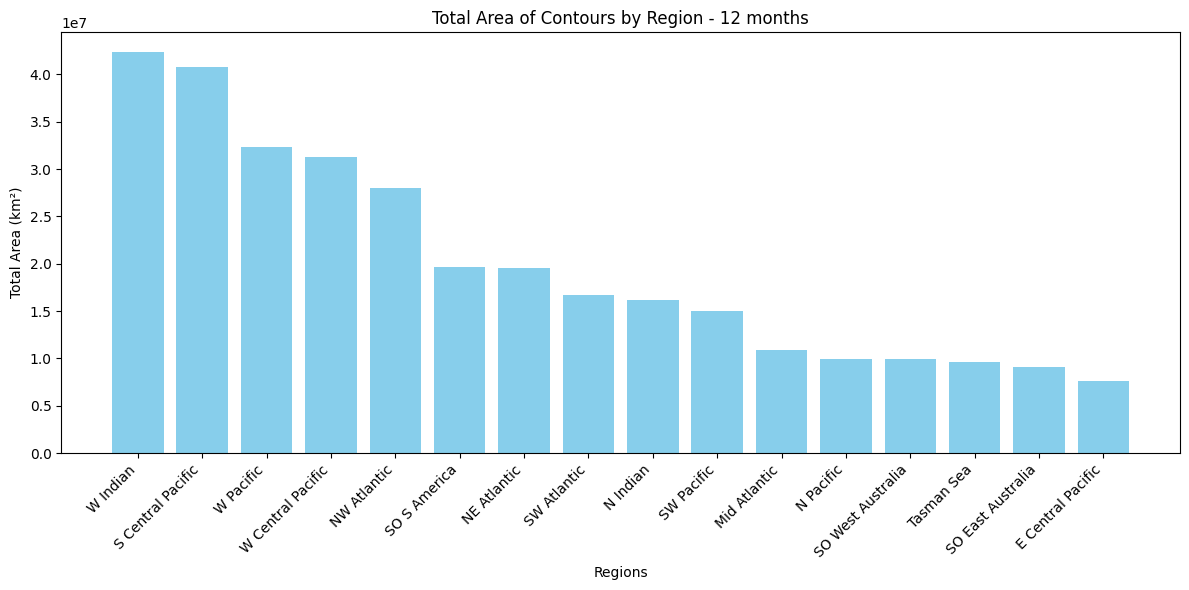

6 months: 225,196,842 km²


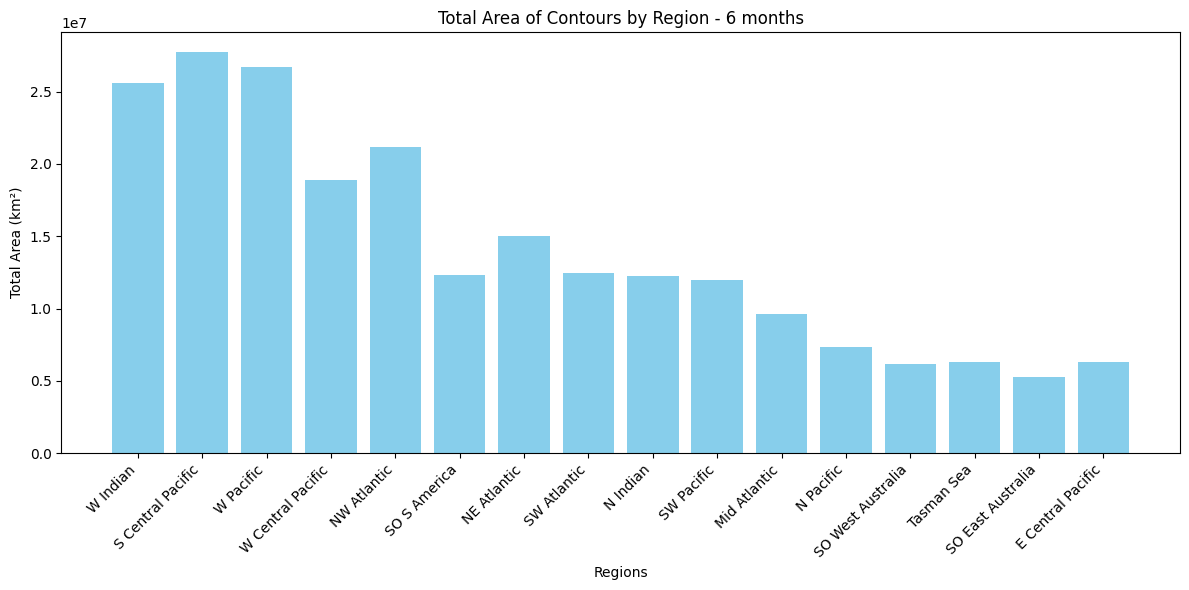

3 months: 156,598,775 km²


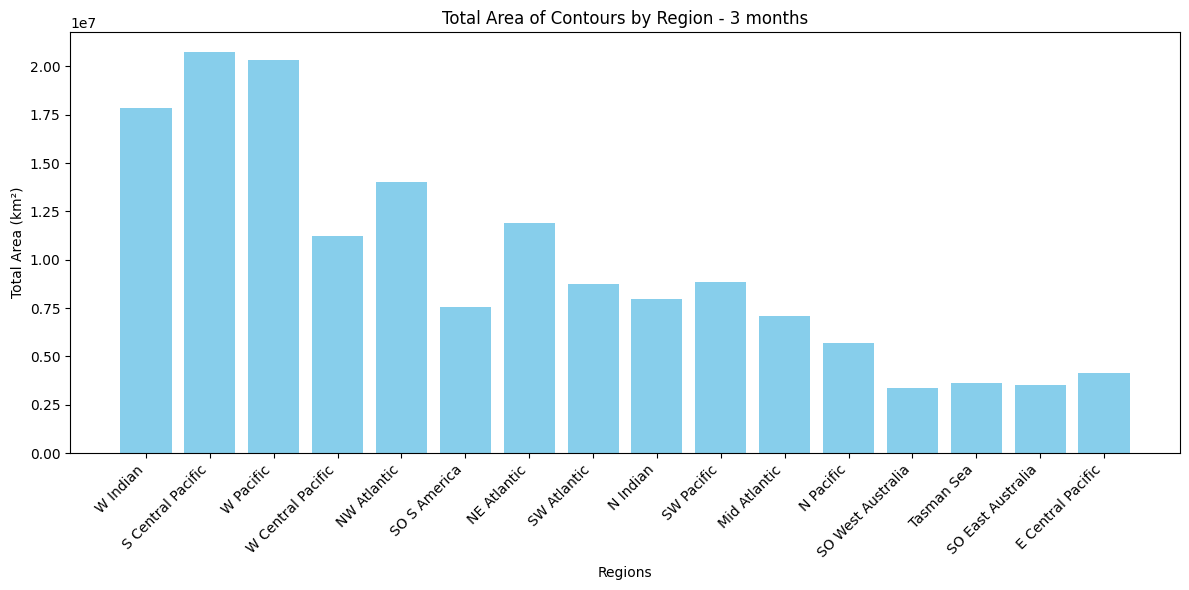

1 month: 90,946,917 km²


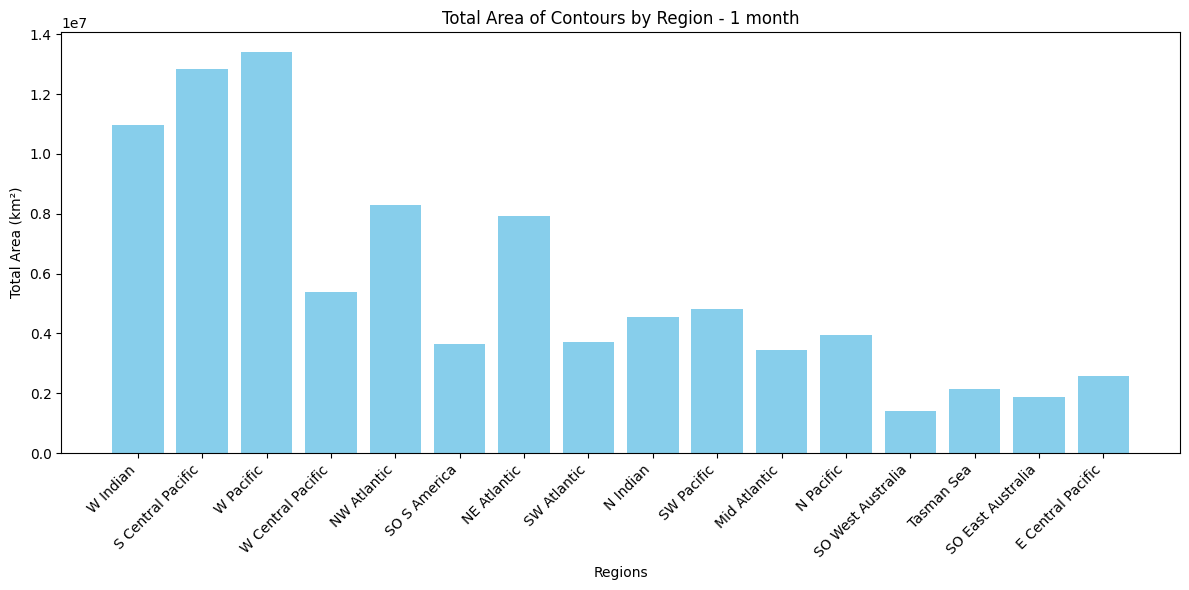

In [17]:
for period_label in PERIOD_ORDER:
    total_area = area_table.loc[period_label].sum()
    print(f"{period_label}: {total_area:,.0f} km²")
    plot_area_bars(
        area_results_by_period[period_label],
        f"Total Area of Contours by Region - {period_label}",
    )


#### initialize final bar plot


In [18]:
regions = watershed_order.copy()
area_12_vals = area_table.loc["12 months"].to_numpy()
area_6_vals = area_table.loc["6 months"].to_numpy()
area_3_vals = area_table.loc["3 months"].to_numpy()
area_1_vals = area_table.loc["1 month"].to_numpy()

area_3_component = np.clip(area_3_vals - area_1_vals, 0, None)
area_6_component = np.clip(area_6_vals - area_3_vals, 0, None)
area_12_component = np.clip(area_12_vals - area_6_vals, 0, None)

stacked_area_table = pd.DataFrame(
    {
        "1 month": area_1_vals,
        "3 months": area_3_component,
        "6 months": area_6_component,
        "12 months": area_12_component,
    },
    index=DISPLAY_LABELS,
)
stacked_area_table


,1 month,3 months,6 months,12 months
W Indian,1.096208e+07,6.873591e+06,7.789492e+06,1.669742e+07
S Central Pacific,1.285046e+07,7.878950e+06,6.991725e+06,1.309121e+07
W Pacific,1.339480e+07,6.927794e+06,6.380668e+06,5.644945e+06
W Central Pacific,5.389658e+06,5.834838e+06,7.686177e+06,1.236854e+07
NW Atlantic,8.279926e+06,5.765373e+06,7.133437e+06,6.846125e+06
SO S America,3.654901e+06,3.877038e+06,4.784647e+06,7.304641e+06
NE Atlantic,7.941280e+06,3.973113e+06,3.097177e+06,4.494094e+06
SW Atlantic,3.716726e+06,5.010554e+06,3.743940e+06,4.176097e+06
N Indian,4.549508e+06,3.421740e+06,4.312074e+06,3.835380e+06
SW Pacific,4.830151e+06,4.015040e+06,3.141836e+06,3.025047e+06


#### final bar plot


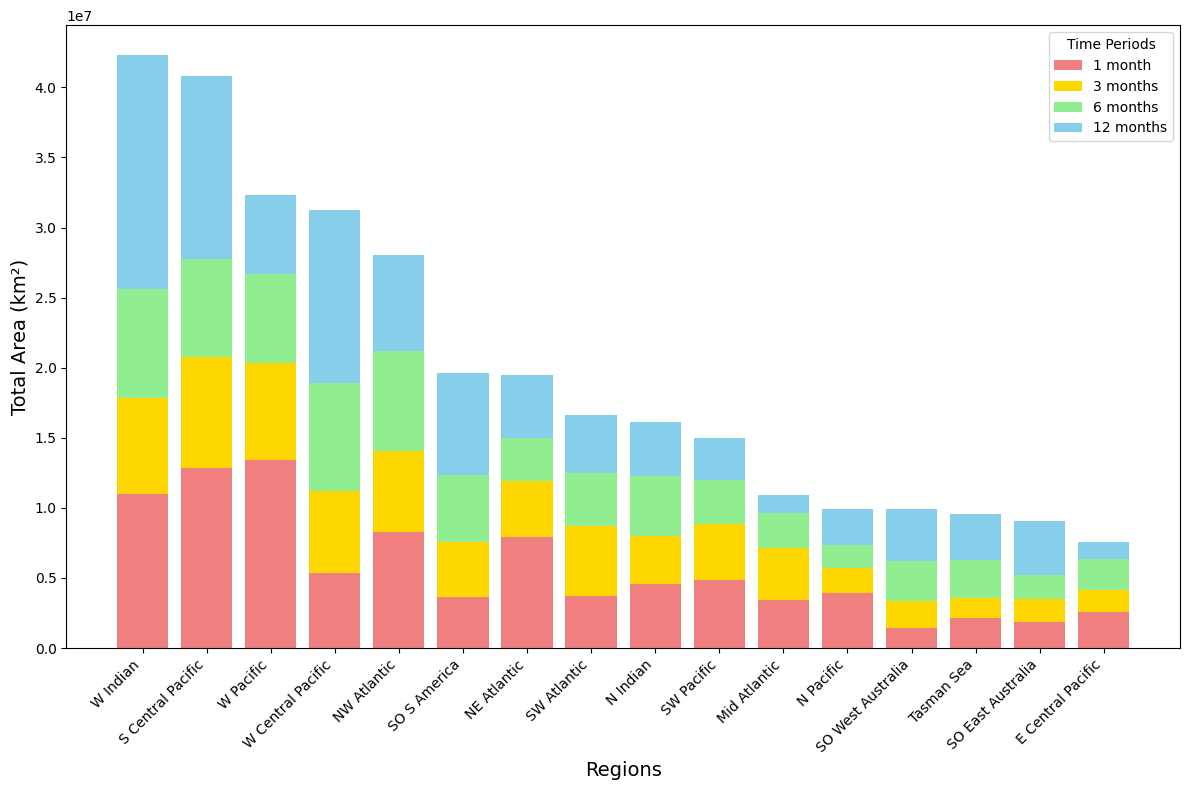

In [19]:
plt.figure(figsize=(12, 8))

plt.bar(DISPLAY_LABELS, area_1_vals, label="1 month", color="lightcoral")
plt.bar(DISPLAY_LABELS, area_3_component, bottom=area_1_vals, label="3 months", color="gold")
plt.bar(
    DISPLAY_LABELS,
    area_6_component,
    bottom=area_1_vals + area_3_component,
    label="6 months",
    color="lightgreen",
)
plt.bar(
    DISPLAY_LABELS,
    area_12_component,
    bottom=area_1_vals + area_3_component + area_6_component,
    label="12 months",
    color="skyblue",
)

plt.xlabel("Regions", fontsize=14)
plt.ylabel("Total Area (km²)", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Time Periods")
plt.tight_layout()
plt.show()


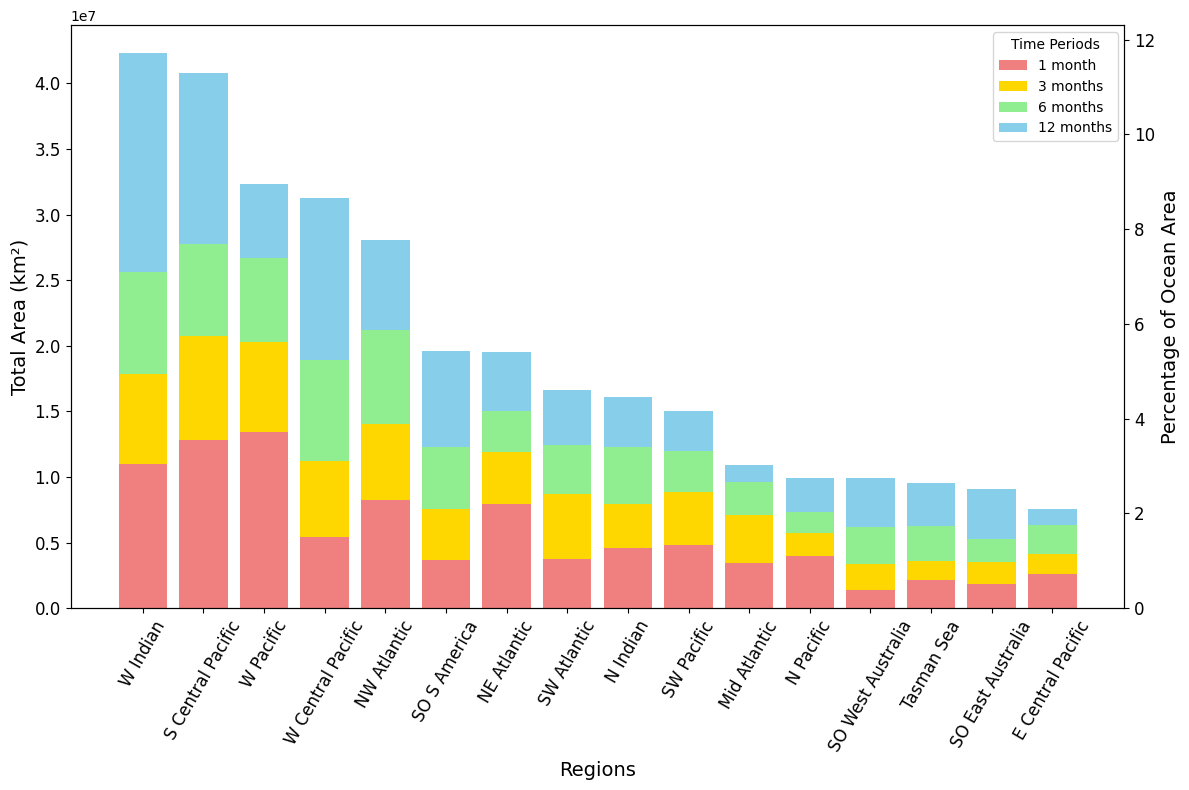

In [20]:
stacked_totals = area_1_vals + area_3_component + area_6_component + area_12_component
primary_y_max = max(stacked_totals.max() * 1.05, 1)

fig, ax1 = plt.subplots(figsize=(12, 8))

ax1.bar(DISPLAY_LABELS, area_1_vals, label="1 month", color="lightcoral")
ax1.bar(DISPLAY_LABELS, area_3_component, bottom=area_1_vals, label="3 months", color="gold")
ax1.bar(
    DISPLAY_LABELS,
    area_6_component,
    bottom=area_1_vals + area_3_component,
    label="6 months",
    color="lightgreen",
)
ax1.bar(
    DISPLAY_LABELS,
    area_12_component,
    bottom=area_1_vals + area_3_component + area_6_component,
    label="12 months",
    color="skyblue",
)

ax1.set_xlabel("Regions", fontsize=14)
ax1.set_ylabel("Total Area (km²)", fontsize=14)
ax1.tick_params(axis="x", rotation=60, labelsize=12)
ax1.tick_params(axis="y", labelsize=12)
ax1.set_ylim(0, primary_y_max)
ax1.legend(title="Time Periods")

ax2 = ax1.twinx()
ax2.set_ylim(0, primary_y_max / TOTAL_OCEAN_AREA_KM2 * 100)
ax2.set_ylabel("Percentage of Ocean Area", fontsize=14)
ax2.tick_params(axis="y", labelsize=12)

plt.tight_layout()
plt.savefig("figs/total_watershed_final", dpi=300)
plt.show()


### area verification


In [21]:
def compare_areas_to_ocean(ocean_area, table):
    coverage_pct = (table / ocean_area) * 100
    total_area = table.sum(axis=1)
    total_coverage_pct = (total_area / ocean_area) * 100

    summary = pd.DataFrame(
        {
            "total_area_km2": total_area,
            "pct_ocean_area": total_coverage_pct,
        }
    )
    return coverage_pct, summary

coverage_table, coverage_summary = compare_areas_to_ocean(TOTAL_OCEAN_AREA_KM2, area_table)

print("Percent of ocean area covered by each watershed contour:")
display(coverage_table.round(3))

print("Combined area across all watersheds:")
coverage_summary.round(3)


Percent of ocean area covered by each watershed contour:


,W_Indian,S_Central_Pacific,W_Pacific,W_Central_Pacific,NW_Atlantic,SO_S_America,NE_Atlantic,SW_Atlantic,N_Indian,SW_Pacific,Mid_Atlantic,N_Pacific,SO_West_Australia,Tasman_Sea,SO_East_Australia,E_Central_Pacific
1 month,3.035,3.558,3.709,1.492,2.293,1.012,2.199,1.029,1.260,1.338,0.958,1.091,0.388,0.591,0.519,0.710
3 months,4.939,5.740,5.627,3.108,3.889,2.086,3.299,2.417,2.207,2.449,1.969,1.582,0.930,0.997,0.971,1.152
6 months,7.096,7.676,7.394,5.236,5.865,3.411,4.157,3.453,3.401,3.319,2.669,2.032,1.713,1.737,1.449,1.750
12 months,11.719,11.301,8.957,8.661,7.760,5.433,5.401,4.610,4.463,4.157,3.025,2.742,2.741,2.650,2.519,2.097


Combined area across all watersheds:


,total_area_km2,pct_ocean_area
1 month,9.094692e+07,25.184
3 months,1.565988e+08,43.363
6 months,2.251968e+08,62.359
12 months,3.186630e+08,88.240


In [22]:
def combined_heatmap(period_label):
    return sum(histograms_by_period[period_label].values())

def plot_combined_heatmap(period_label, percentile=80):
    heatmap_data = combined_heatmap(period_label)
    positive_cells = heatmap_data[heatmap_data > 0]

    if positive_cells.size == 0:
        raise ValueError(f"No populated grid cells found for {period_label}")

    contour_level = float(np.percentile(positive_cells, percentile))

    fig, ax = plt.subplots(figsize=(15, 7))
    mesh = ax.pcolormesh(
        lon_centers,
        lat_centers,
        heatmap_data,
        cmap="viridis",
        shading="auto",
    )
    contour = ax.contour(
        lon_centers,
        lat_centers,
        heatmap_data,
        levels=[contour_level],
        colors="white",
        linewidths=1.5,
    )

    ax.set_xlim(-180, 180)
    ax.set_ylim(-70, 70)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"{period_label} Combined Trajectory Density Heatmap")
    plt.colorbar(mesh, ax=ax, orientation="vertical", shrink=0.8, label="Heatmap Density")
    plt.tight_layout()
    plt.show()

    total_area = contour_area_from_segments(contour.allsegs[0]) if contour.allsegs[0] else 0.0
    coverage_percentage = (total_area / TOTAL_OCEAN_AREA_KM2) * 100

    return {
        "area_km2": total_area,
        "coverage_pct": coverage_percentage,
        "contour_level": contour_level,
    }


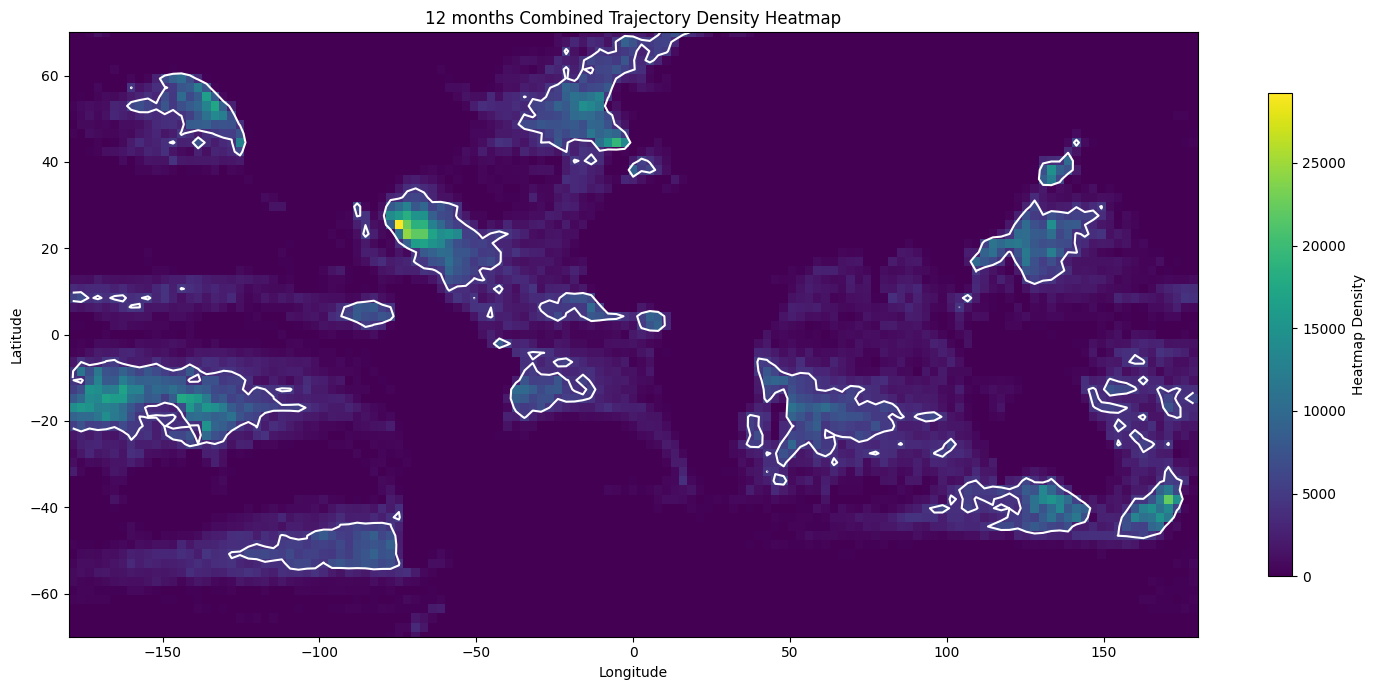

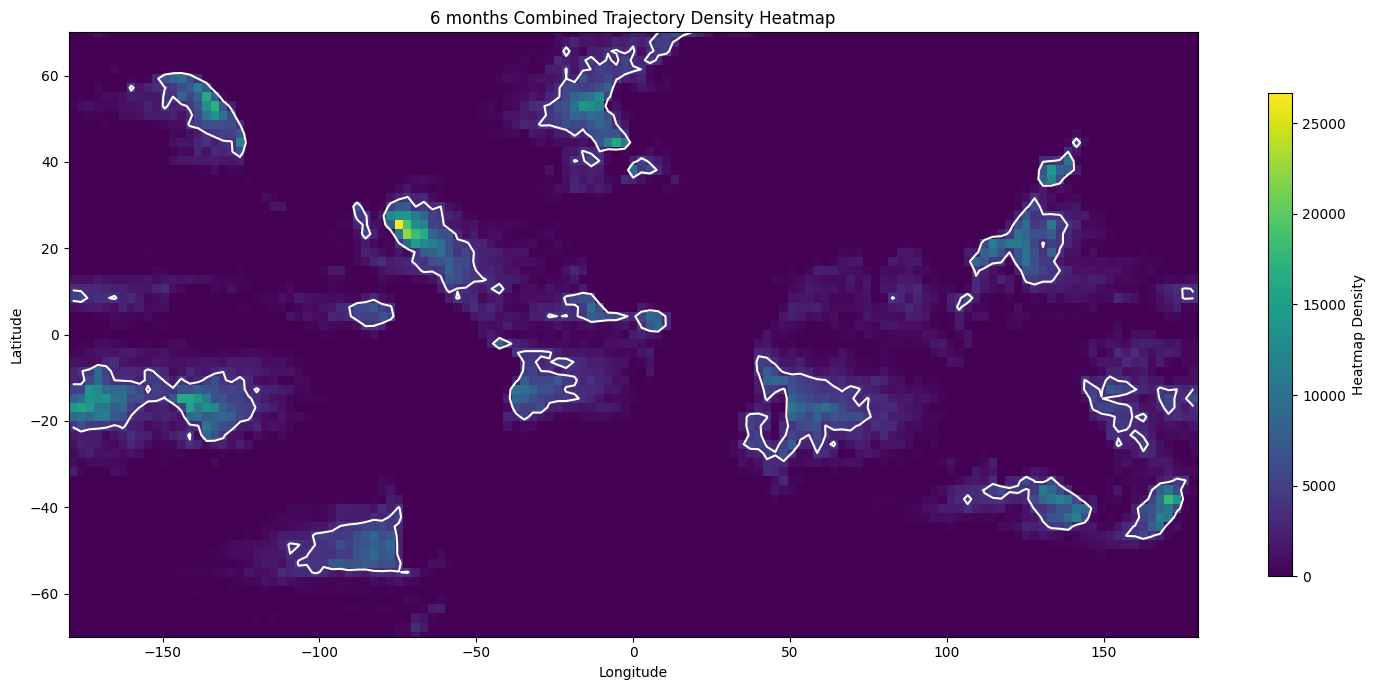

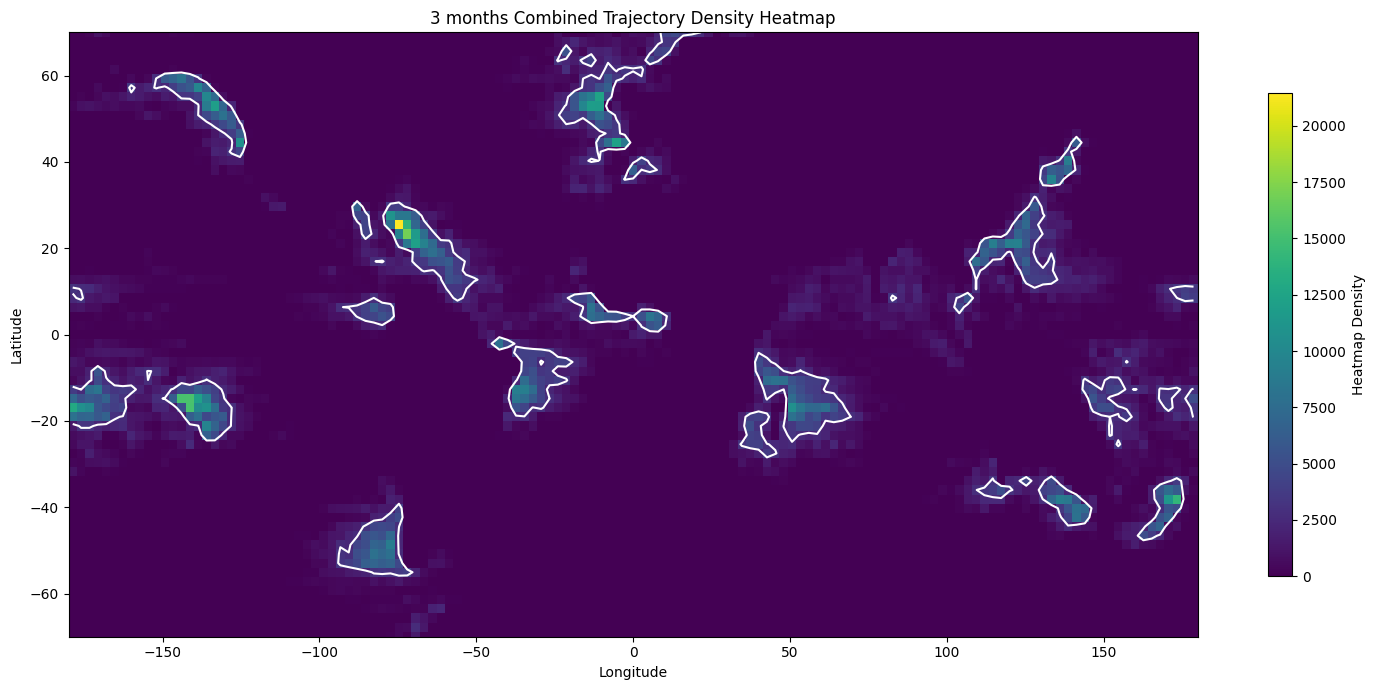

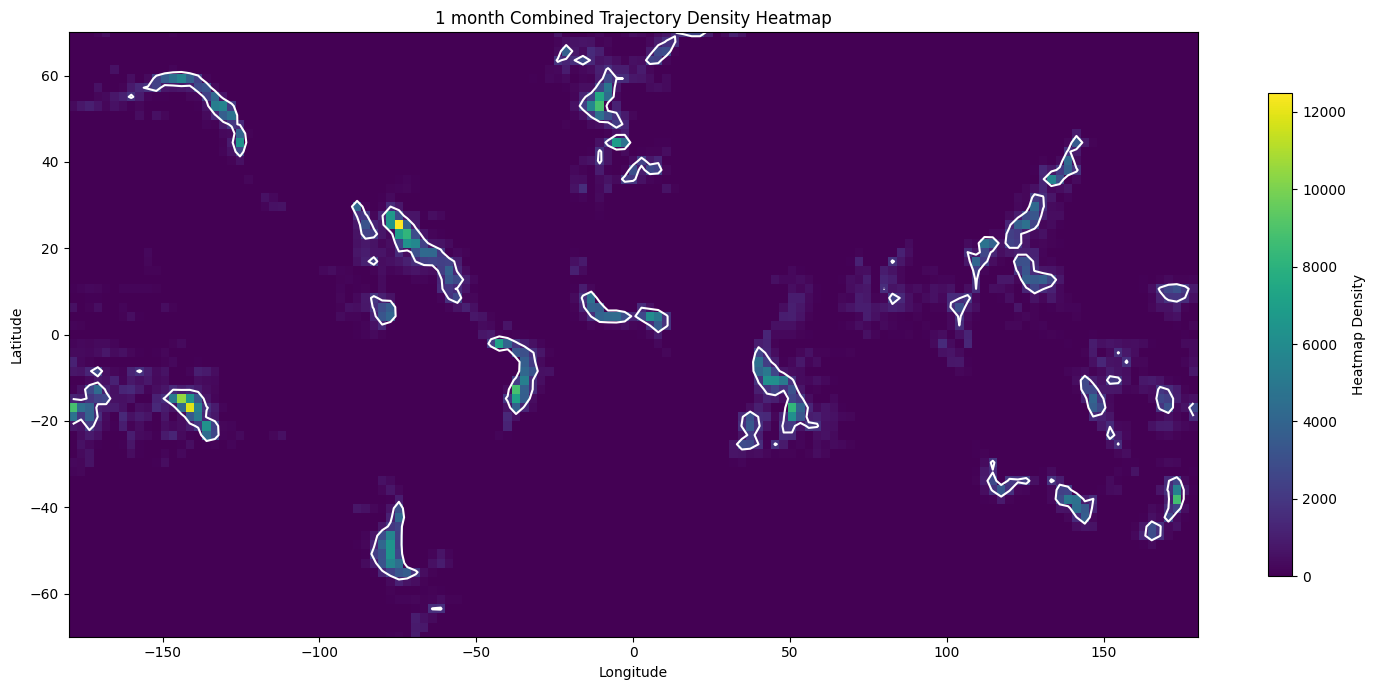

,area_km2,coverage_pct,contour_level
12 months,4.842587e+07,13.409,4399.0
6 months,3.732036e+07,10.334,3671.6
3 months,2.840703e+07,7.866,2763.0
1 month,1.778363e+07,4.924,1577.0


In [23]:
combined_heatmap_summary = pd.DataFrame(
    {
        period_label: plot_combined_heatmap(period_label)
        for period_label in PERIOD_ORDER
    }
).T

combined_heatmap_summary.round(3)
